In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk

In [220]:
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('omw-1.4')
# nltk.download('averaged_perceptron_tagger')

In [221]:
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [222]:
data = pd.read_csv('Tesla-Deaths.csv')

In [223]:
data.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


In [224]:
data.columns

Index(['Case #', 'Year', 'Date', ' Country ', ' State ', ' Description ',
       ' Deaths ', ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
       'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ',
       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 '],
      dtype='object')

In [225]:
data.isnull().sum()

Case #                                                                   13
Year                                                                     13
Date                                                                     13
 Country                                                                 13
 State                                                                   13
 Description                                                             12
 Deaths                                                                   8
 Tesla driver                                                            13
 Tesla occupant                                                          17
 Other vehicle                                                           12
 Cyclists/ Peds                                                          11
 TSLA+cycl / peds                                                        10
 Model                                                                   11
 Autopilot c

In [226]:
data.describe()

,Case #,Year,Deaths,Deceased 4
count,294.000000,294.000000,299.000000,0.0
mean,147.500000,2013.850340,10.284281,NaN
std,85.014705,106.050207,119.032014,NaN
min,1.000000,202.000000,1.000000,NaN
25%,74.250000,2019.000000,1.000000,NaN
50%,147.500000,2021.000000,1.000000,NaN
75%,220.750000,2022.000000,1.000000,NaN
max,294.000000,2022.000000,2013.000000,NaN


In [227]:
missing_values = data.isna()

In [228]:
missing_values

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
303,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
304,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
305,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


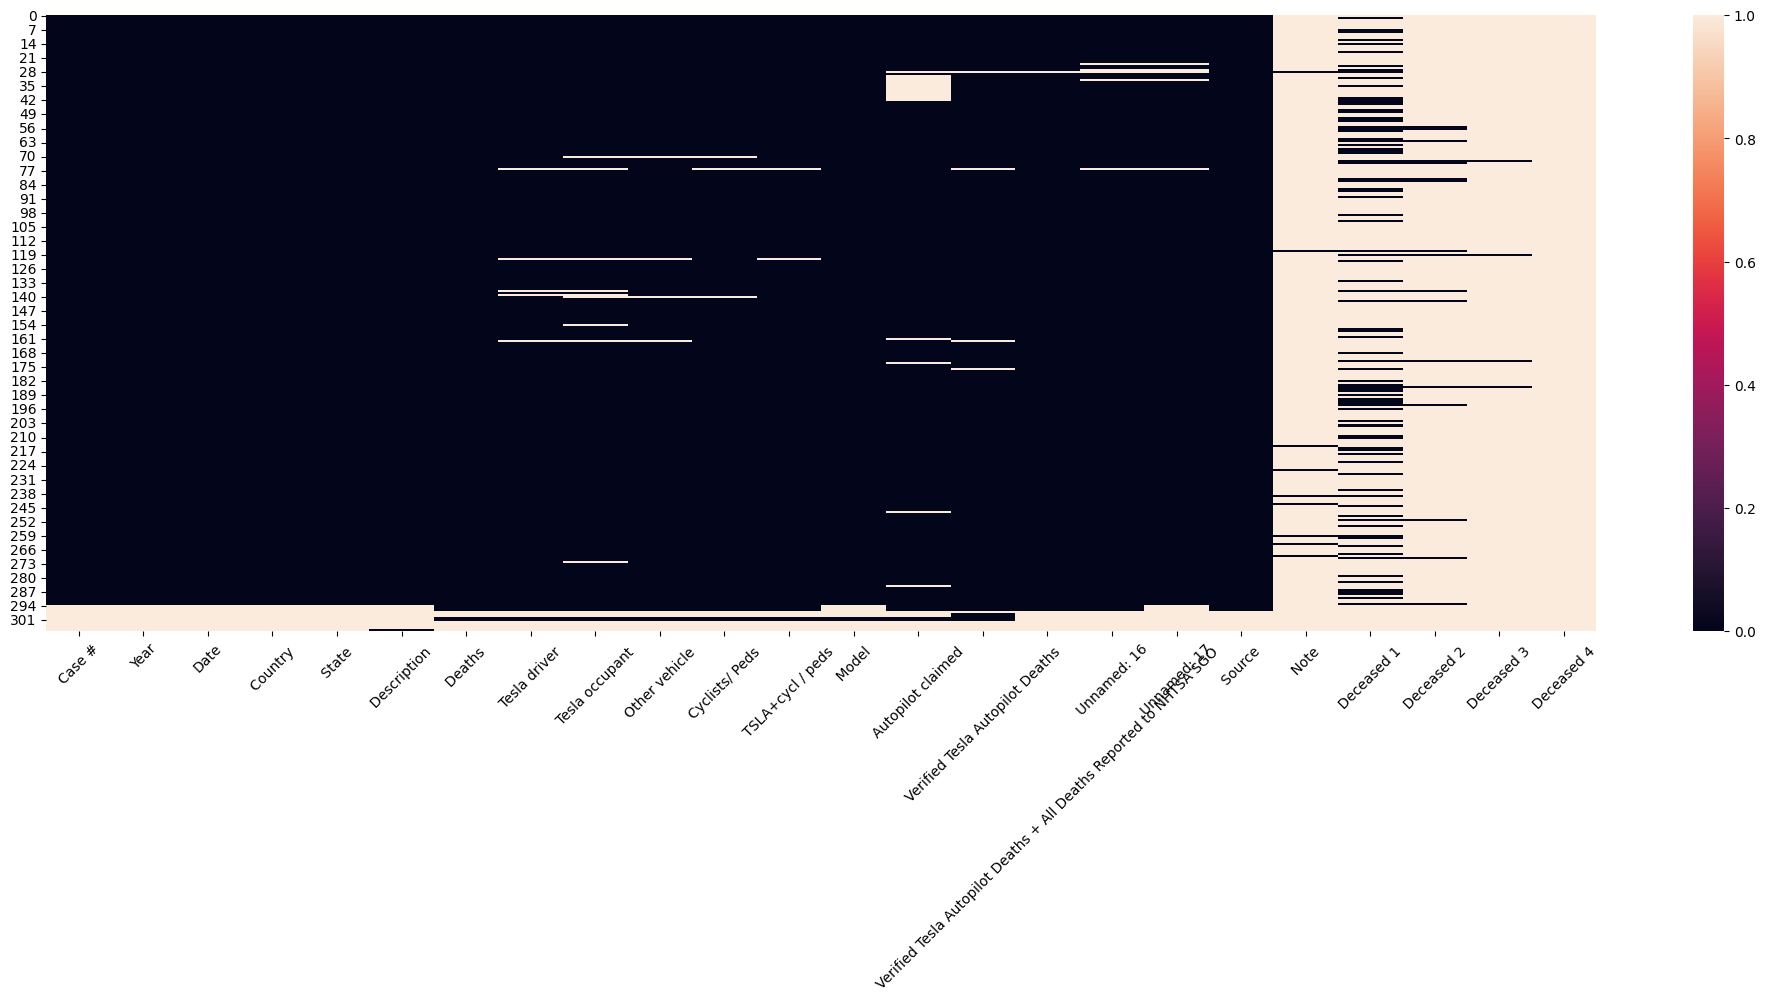

In [229]:
plt.figure(figsize=(25, 8))
sns.heatmap(missing_values)
plt.xticks(rotation=45)
plt.show()

In [230]:
data.shape

(307, 24)

In [231]:
data.columns

Index(['Case #', 'Year', 'Date', ' Country ', ' State ', ' Description ',
       ' Deaths ', ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
       'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ',
       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 '],
      dtype='object')

In [232]:
drop_cols = ['Case #', 'Year','Unnamed: 16', 'Unnamed: 17',' Deceased 1 ',' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 ', ' Source ']

In [233]:
data.drop(columns=drop_cols, inplace=True)

In [234]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
       ' Note '],
      dtype='object')

In [235]:
data[' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO '].value_counts()

 Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO 
-       269
 1       21
 2        3
 3        1
 24       1
 27       1
Name: count, dtype: int64

In [236]:
data.drop(columns=' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ', inplace=True)

In [237]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ', ' Note '],
      dtype='object')

In [238]:
data[' Note '].isna().sum()

np.int64(298)

In [239]:
data[' Note '].unique()

array([nan,
       ' Received confirmation from family friend that it was a Tesla ',
       ' Contacted by close friend who disclosed the car was a Tesla. Awaiting further confirmation. ',
       ' AP claimed in NHTSA complaint ', ' Case ID: 91121642 ',
       ' Car model confirmed in personal correspondence ',
       ' John Renner, investigation #18119-2207 ',
       ' Twitter search for "Cruzelite" and "Tesla" confirms Joel owned a Tesla. Also had a TMC account. ',
       ' News report describes a speeding driver striking a Tesla; video footage and Copart photos of car show an unblemished Tesla missing a rear wheel, suggesting another of Tesla\'s characteristic "snap off" wheels ',
       ' In NHTSA-FARS database, CaseNum=964&StateNum=17&CaseYear=2016 '],
      dtype=object)

In [240]:
# As note is not adding any valur so we can drop Note col as well 
data.drop(columns=' Note ', inplace=True)

In [241]:
missing_values = data.isna()

In [242]:
missing_values

,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,True,True,True,True,True,True,True,True,True,True,True,True,True
303,True,True,True,True,True,True,True,True,True,True,True,True,True
304,True,True,True,True,True,True,True,True,True,True,True,True,True
305,True,True,True,True,True,True,True,True,True,True,True,True,True


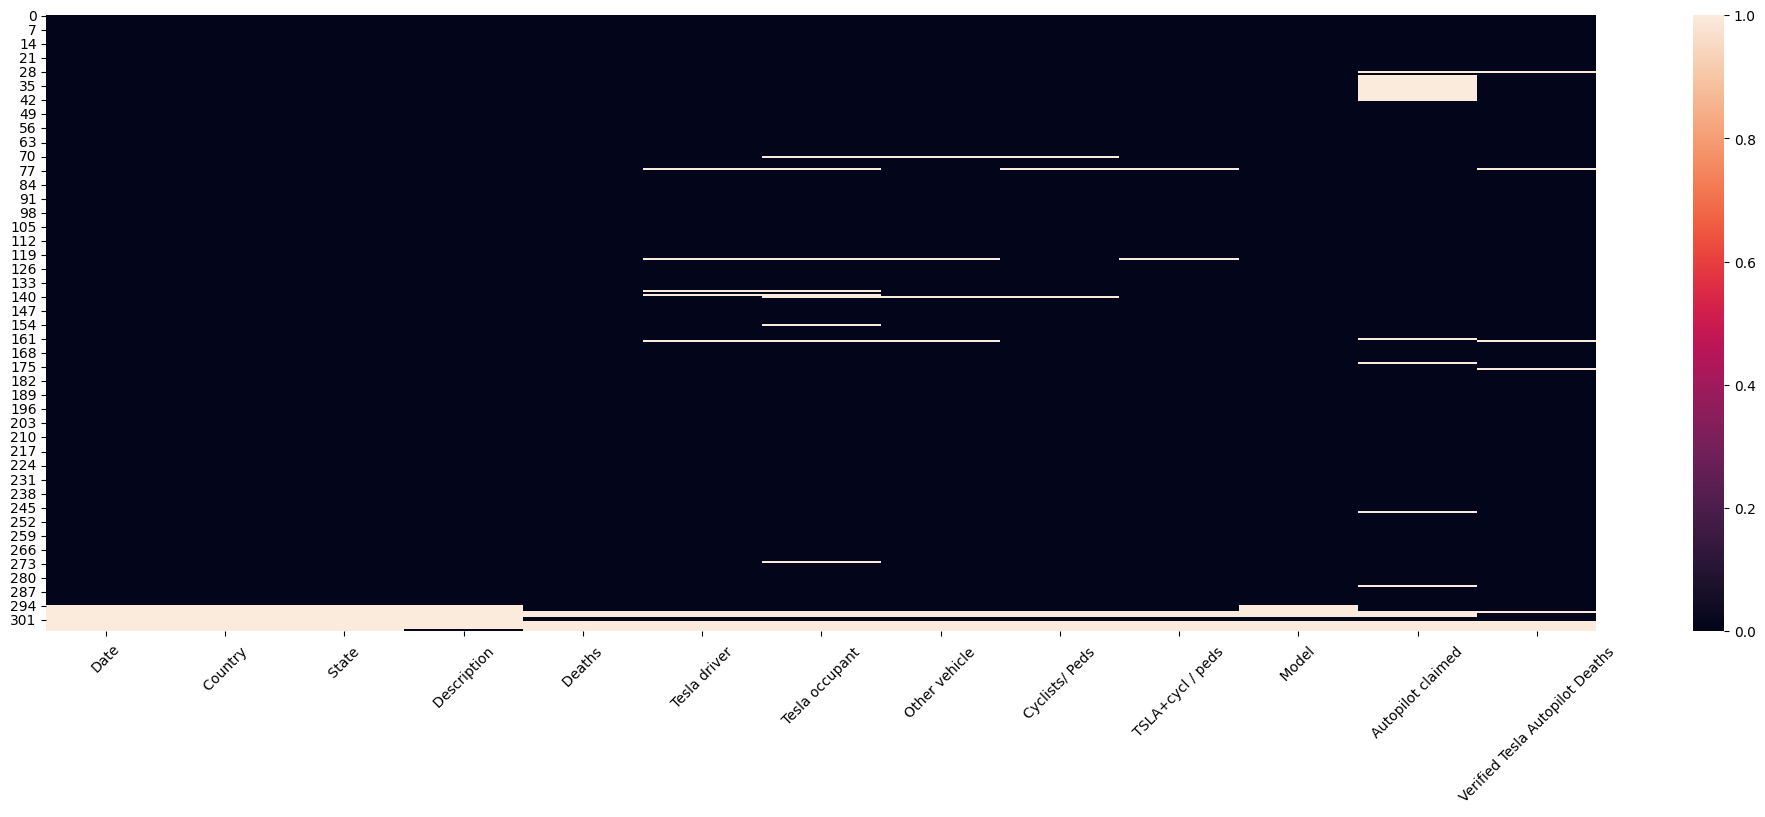

In [243]:
plt.figure(figsize=(25, 8))
sns.heatmap(missing_values)
plt.xticks(rotation=45)

plt.show()

In [244]:
data.head()

,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,-,1,-,-,-
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,-,1,-,-,-
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,-,1,-,-,-
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,-,1,-,-,-
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,1,1,-,-,-


In [245]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths '],
      dtype='object')

In [246]:
data.columns[5:]

Index([' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths '],
      dtype='object')

In [247]:
cols = data.columns[5:]
for col in cols:
    if col != ' Model ':
        data[col] = data[col].fillna('-')
        data[col] = data[col].str.strip()
        data[col] = data[col].replace('-', '0')
        data[col] = data[col].astype(int)
        print(data[col].unique())
        

[   1    0   28   89  117    6 2014]
[   0    1    3    2    7   41   48    5 2015]
[   0    1    2    3    4   29  101  130   16 2016]
[   0    1    2   20   26   46   11 2017]
[   1    0    2    3    4   61  149  210   21 2018]
[   0    1    2    8   30   38   47 2020]
[   0    1    2    3   16   19  118 2022   75 2021]


In [248]:
data.isnull().sum()

Date                                 13
 Country                             13
 State                               13
 Description                         12
 Deaths                               8
 Tesla driver                         0
 Tesla occupant                       0
 Other vehicle                        0
 Cyclists/ Peds                       0
 TSLA+cycl / peds                     0
 Model                               11
 Autopilot claimed                    0
 Verified Tesla Autopilot Deaths      0
dtype: int64

In [249]:
data.dropna(inplace=True)

In [250]:
data.isnull().sum()

Date                                 0
 Country                             0
 State                               0
 Description                         0
 Deaths                              0
 Tesla driver                        0
 Tesla occupant                      0
 Other vehicle                       0
 Cyclists/ Peds                      0
 TSLA+cycl / peds                    0
 Model                               0
 Autopilot claimed                   0
 Verified Tesla Autopilot Deaths     0
dtype: int64

In [251]:
missing_values = data.isna()

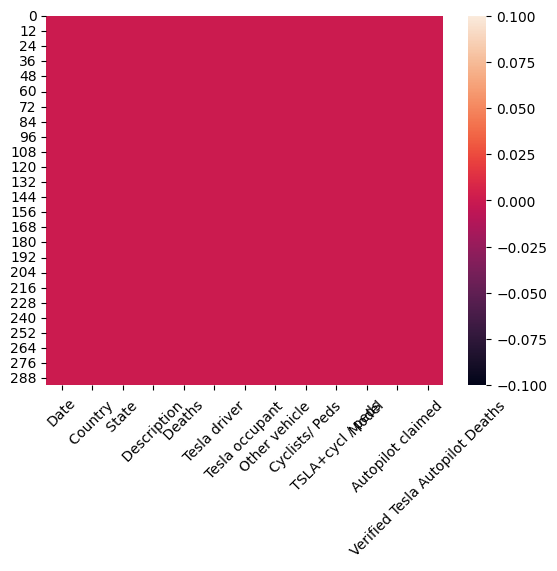

In [252]:
sns.heatmap(missing_values)
plt.xticks(rotation=45)
plt.show()

## Change the variables Names 

In [253]:
data.columns = data.columns.str.strip()
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla driver',
       'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 'TSLA+cycl / peds',
       'Model', 'Autopilot claimed', 'Verified Tesla Autopilot Deaths'],
      dtype='object')

In [254]:
data.columns = data.columns.str.replace(' ', '').str.replace("[+/-]", "_" , regex=True) 

In [255]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesladriver',
       'Teslaoccupant', 'Othervehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Autopilotclaimed', 'VerifiedTeslaAutopilotDeaths'],
      dtype='object')

In [256]:
data.rename(columns={'Autopilotclaimed':'Autopilot_Claimed', 'VerifiedTeslaAutopilotDeaths':'VTAD', 'Teslaoccupant': 'Tesla_Occupant', 'Tesladriver': 'Tesla_Driver', 'Othervehicle': 'Other_Vehicle' }, inplace=True)

In [257]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla_Driver',
       'Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Autopilot_Claimed', 'VTAD'],
      dtype='object')

## EDA

In [258]:
data.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Autopilot_Claimed,VTAD
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0


In [259]:
# Converting Date column values in correct date format
data.Date = pd.to_datetime(data.Date)

In [260]:
# Adding new column : Year, Month & Day in which accident happened
data.loc[:, "event_year"] = data.Date.dt.year
data.loc[:, "event_month"] = data.Date.dt.month
data.loc[:, "event_day"] = data.Date.dt.day

In [261]:
data.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Autopilot_Claimed,VTAD,event_year,event_month,event_day
0,2023-01-17,USA,CA,Tesla crashes into back of semi,1.0,1,0,0,0,1,-,0,0,2023,1,17
1,2023-01-07,Canada,-,Tesla crashes,1.0,1,0,0,0,1,-,0,0,2023,1,7
2,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1.0,0,1,0,0,1,-,0,0,2023,1,7
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19


In [262]:
# Now check accident counts per year 
data.event_year.value_counts().sort_index()

event_year
2013     2
2014     4
2015     5
2016    15
2017    11
2018    18
2019    46
2020    39
2021    58
2022    93
2023     3
Name: count, dtype: int64

In [263]:
# 2013, 2014, 2015 & 2023 are having very less number of accidents so we can remove these years from our data having accident count less than 5
data_new = data[(data.event_year >= 2015) & (data.event_year != 2023)] 

In [264]:
data_new.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Autopilot_Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,-,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,-,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,-,0,0,2022,12,11


In [265]:
data_new.event_year.value_counts().sort_index()


event_year
2015     5
2016    15
2017    11
2018    18
2019    46
2020    39
2021    58
2022    93
Name: count, dtype: int64

/tmp/ipykernel_7249/2449767176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='event_year', data=data_new, palette='viridis')


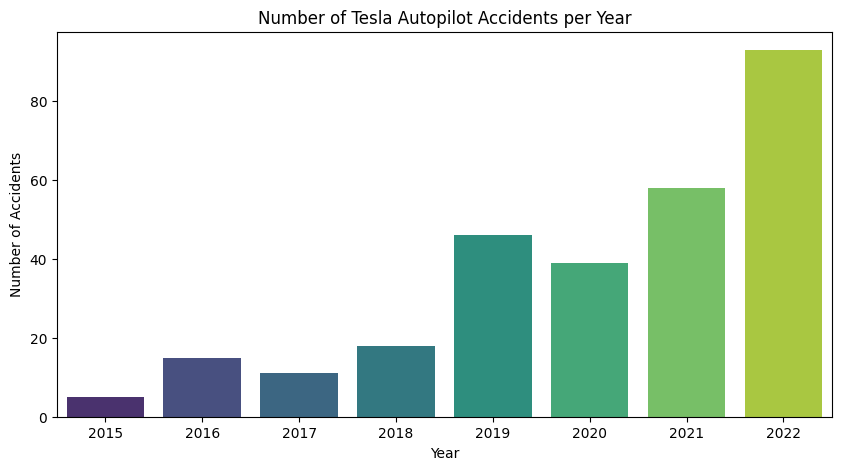

In [266]:
# Now building and plotting values on Graph - 
plt.figure(figsize=(10, 5))
sns.countplot(x='event_year', data=data_new, palette='viridis')
plt.title('Number of Tesla Autopilot Accidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()


In [267]:
# Month vise 
vc_month = data_new.event_month.value_counts().sort_index()
vc_month

event_month
1     18
2      9
3     24
4     22
5     28
6     28
7     24
8     24
9     26
10    16
11    34
12    32
Name: count, dtype: int64

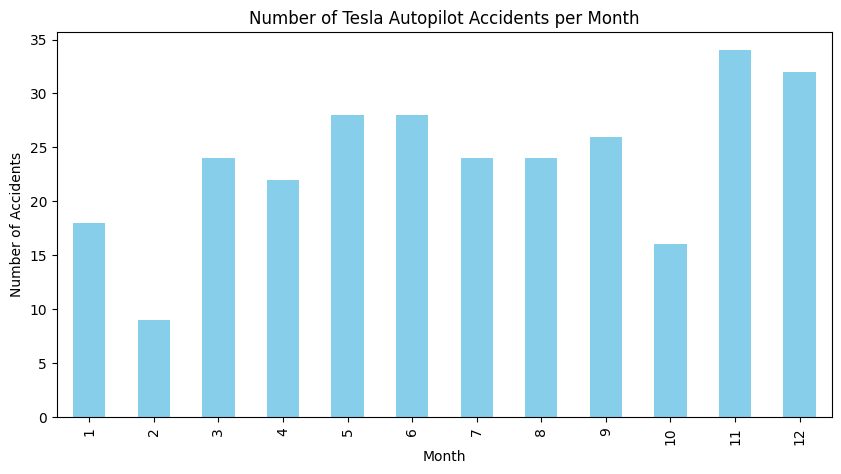

In [268]:
vc_month.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Number of Tesla Autopilot Accidents per Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()

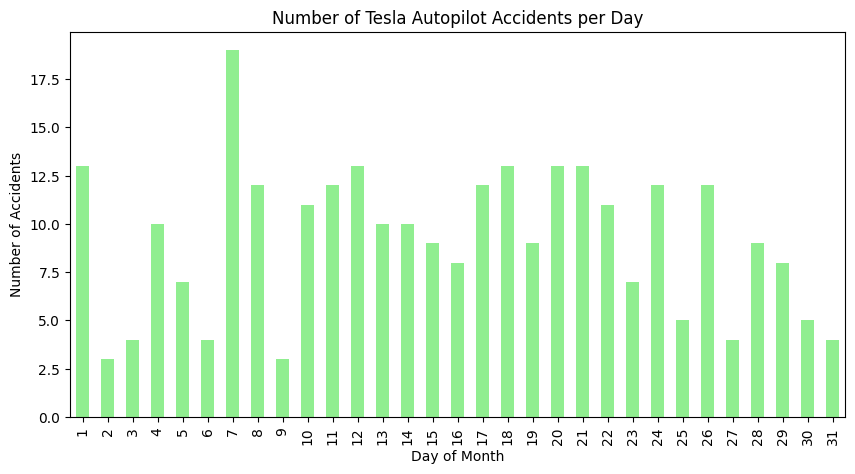

In [269]:
# day Wise 
vc_day = data_new.event_day.value_counts().sort_index()
vc_day.plot(kind='bar', figsize=(10, 5), color='lightgreen')
plt.title('Number of Tesla Autopilot Accidents per Day')
plt.xlabel('Day of Month')
plt.ylabel('Number of Accidents')
plt.show()

In [270]:
data_new.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Autopilot_Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,-,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,-,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,-,0,0,2022,12,11


In [271]:
data_new.Model.value_counts()

Model
-      173
S       44
 3      39
X       17
Y       10
 1       1
 2       1
Name: count, dtype: int64

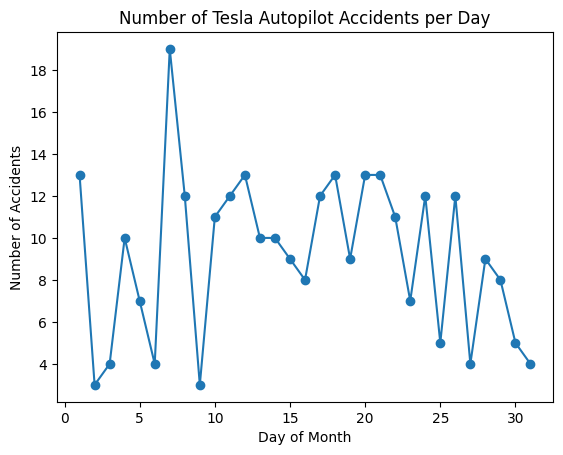

In [272]:
vc_day = data_new.event_day.value_counts().sort_index()
plt.Figure(figsize=(12, 6))
plt.plot(vc_day.index, vc_day.values)
plt.scatter(vc_day.index, vc_day.values)
plt.xlabel('Day of Month')
plt.ylabel('Number of Accidents')
plt.title('Number of Tesla Autopilot Accidents per Day')
plt.show()

# Conclusion 

## Accidents ts BY Country 

/tmp/ipykernel_7249/1329923731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette='magma')


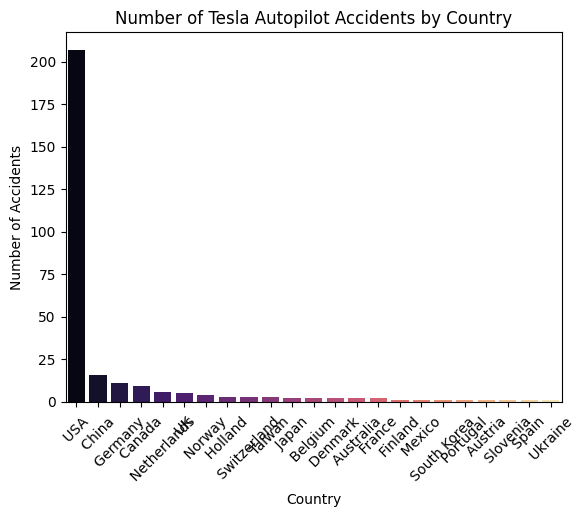

In [273]:
vc = data_new.Country.value_counts()
plt.Figure(figsize=(12, 6))
sns.barplot(x=vc.index, y=vc.values, palette='magma')
plt.title('Number of Tesla Autopilot Accidents by Country')
plt.xlabel('Country')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

## Accidents by State

/tmp/ipykernel_7249/2692044714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette='coolwarm')


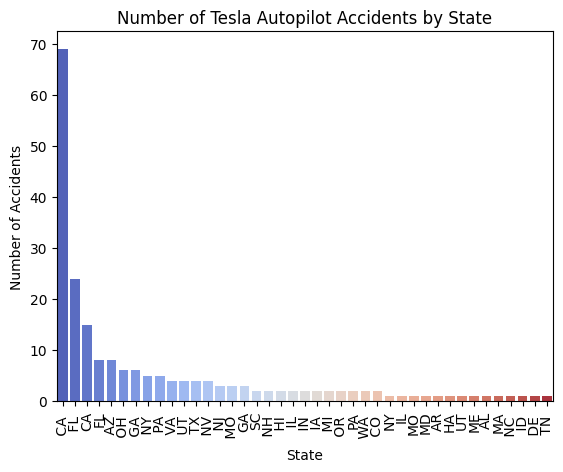

In [274]:
vc = data_new.State.value_counts()
vc = vc[vc.index != '-']
plt.Figure(figsize=(12, 6))
sns.barplot(x=vc.index, y=vc.values, palette='coolwarm')
plt.title('Number of Tesla Autopilot Accidents by State')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)
plt.show()

## Accidents by Model 

In [283]:

data_new.Model.replace('-', 'UNKNOWN', inplace=True)
data_new.Model  = data_new.Model.str.strip()

/tmp/ipykernel_7249/1220443044.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_new.Model.replace('-', 'UNKNOWN', inplace=True)
/tmp/ipykernel_7249/1220443044.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new.Model.replace('-', 'UNKNOWN', inplace=True)
/tmp/ipykernel_7249/1220443044.py:2: SettingWithCopyWarning: 
A value is 

In [284]:
vc = data_new.Model.value_counts()

vc 


Model
UNKNOWN    173
S           44
3           39
X           17
Y           10
1            1
2            1
Name: count, dtype: int64

/tmp/ipykernel_7249/2991128450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette='Spectral')


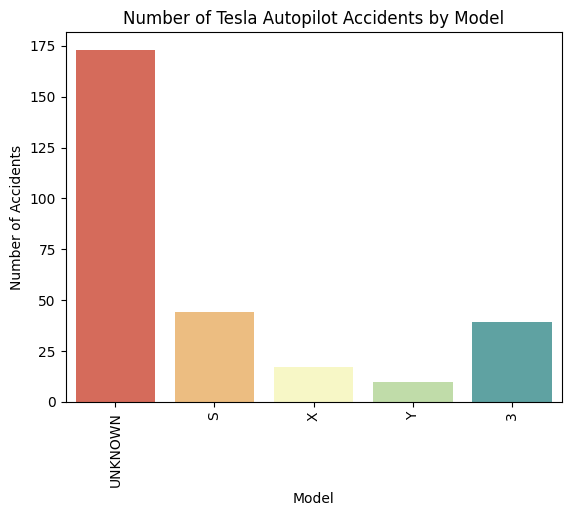

In [285]:
vc = vc[["UNKNOWN", "S", "X", "Y", "3"]]
plt.Figure(figsize=(12, 6))
sns.barplot(x=vc.index, y=vc.values, palette='Spectral')
plt.title('Number of Tesla Autopilot Accidents by Model')
plt.xlabel('Model')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)
plt.show()

In [287]:
vc = data.VTAD.value_counts()
vc 


VTAD
0    278
1     13
2      3
Name: count, dtype: int64

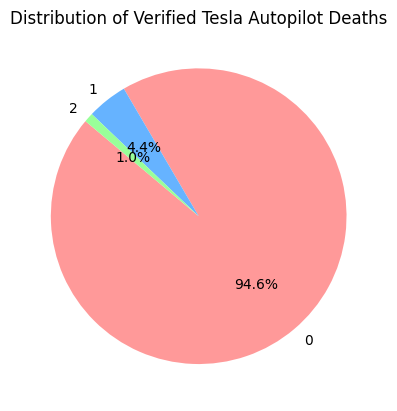

In [290]:
plt.Figure(figsize=(12, 6))
vc.plot.pie(autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribution of Verified Tesla Autopilot Deaths')
plt.ylabel('')
plt.show()

### 2 (b) Analysis of Data

In [291]:
data_new.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Autopilot_Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,UNKNOWN,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,UNKNOWN,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,UNKNOWN,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,UNKNOWN,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,UNKNOWN,0,0,2022,12,11


In [300]:
data_new.Deaths.sum()

np.float64(341.0)

####  Total number of Death by Tesla Vehicle= 341

In [299]:
data_new.Tesla_Driver.sum()

np.int64(113)

#### How Many times Tesl Driver Dies : 113

### What is the proportion of events in which one or more occupants died?

In [302]:
total_events = len(data_new)
total_events

285

In [304]:
events_w_occupant_death = data_new[data_new.Tesla_Occupant > 0]
events_w_occupant_death_count = len(events_w_occupant_death)
events_w_occupant_death_count

42

In [ ]:
proportion_of_death = events_w_occupant_death_count / total_events
proportion_of_death*100

14.736842105263156

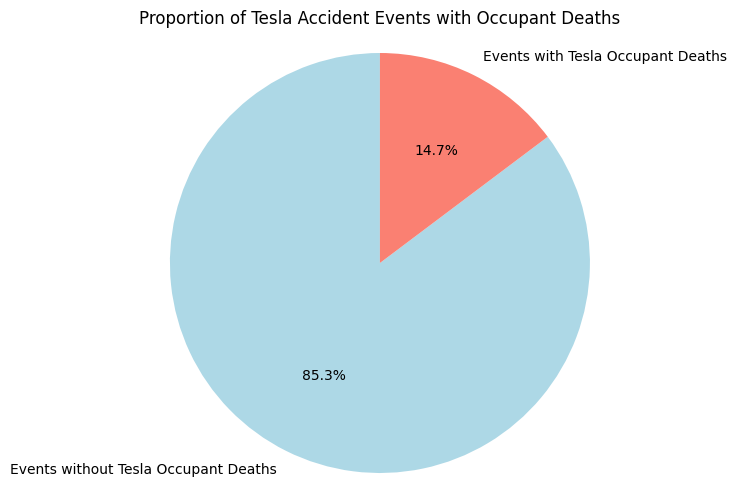

In [307]:
# Visualization 
labels = ['Events without Tesla Occupant Deaths', 'Events with Tesla Occupant Deaths']
sizes = [total_events - events_w_occupant_death_count, events_w_occupant_death_count]
colors = ['lightblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proportion of Tesla Accident Events with Occupant Deaths')
plt.axis('equal')
plt.show()

### What is the distribution of events in which the vehicle hit a cyclist or a pedestrian?

In [308]:
count_cyclist_ped_events = len(data_new[data_new.Cyclists_Peds > 0])
count_cyclist_ped_events

43

In [310]:
distribution_cyclist_ped_death = count_cyclist_ped_events/total_events 
distribution_cyclist_ped_death*100

15.087719298245613

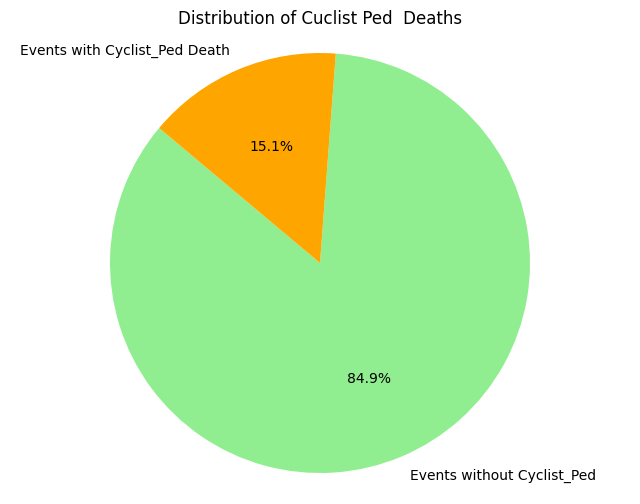

In [314]:
#Visualization
labels = ['Events without Cyclist_Ped', 'Events with Cyclist_Ped Death']
sizes = [total_events - count_cyclist_ped_events, count_cyclist_ped_events]
colors = ['lightgreen', 'orange']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Distribution of Cuclist Ped  Deaths')
plt.axis('equal')
plt.show()

### How many times did the accident involve the death of an occupant or driver of a Tesla  long with a cyclist or pedestrian?

In [322]:
tesla_death = (data_new.Tesla_Driver > 0) | (data_new.Tesla_Occupant > 0)
tesla_death

3       True
4      False
5       True
6      False
7       True
       ...  
283     True
284     True
285    False
286     True
287     True
Length: 285, dtype: bool

In [325]:
both_death = tesla_death & (data_new.Cyclists_Peds > 0)
len(data_new[both_death])

1

### What is the frequency of Tesla colliding with other vehicles?

In [327]:
collid_w_other_vehicle = data_new[data_new.Other_Vehicle > 0]
count_collid_other_vehicle = len(collid_w_other_vehicle)

In [330]:
freq = count_collid_other_vehicle / total_events
freq * 100

37.54385964912281

Other vehicle deaths per collision event:
Other_Vehicle
1    94
2    10
3     2
4     1
Name: count, dtype: int64


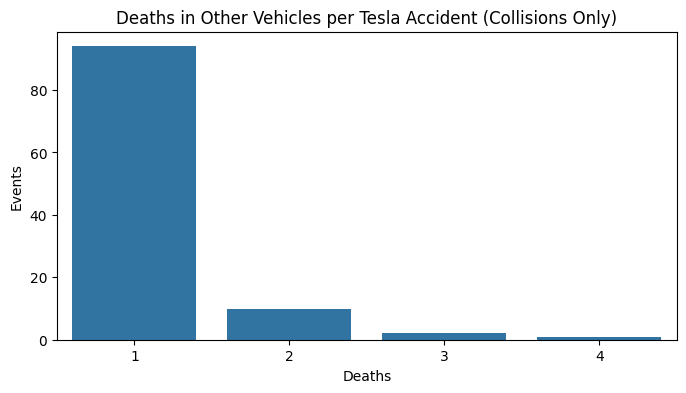

In [331]:
#Visualization 
distribution = collid_w_other_vehicle.Other_Vehicle.value_counts().sort_index()
print("Other vehicle deaths per collision event:")
print(distribution)

# Visualize
plt.figure(figsize=(8, 4))
sns.barplot(x=distribution.index, y=distribution.values)
plt.title('Deaths in Other Vehicles per Tesla Accident (Collisions Only)')
plt.xlabel('Deaths')
plt.ylabel('Events')
plt.show()